In [209]:
import time
start_time = time.time()

# Make sure to have "Quotes.csv" to run this notebook.

In [210]:
import numpy as np
import matplotlib.pyplot as plt

def get_bid_ask(file_path):
    quotes = []
    with open(file_path, 'r') as f:
        import csv
        reader = csv.reader(f)
        for row in reader:
            if len(row) >= 3:
                quotes.append([float(row[0]), float(row[2]), float(row[1])])
    return np.array(quotes)

def load_c_values(R1, R2, S0, theta):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    c_v1_unit = []
    dist0 = nus1_full[1] - nus1_full[0]
    c_v1_unit.append((-np.exp(-dist0/sigs1[0]), np.exp(dist0/sigs1[0])))
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        c_v1_unit.append((0.5 * (P - sigs1[j+1]*S) * np.exp(-dist/sigs1[j+1]), 0.5 * (P + sigs1[j+1]*S) * np.exp(dist/sigs1[j+1])))
    c_v2_unit = [None] * R2
    dist_u = nus2_full[-1] - nus2_full[-2]
    c_v2_unit[-1] = (np.exp(dist_u/sigs2[-1]), -np.exp(-dist_u/sigs2[-1]))
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2_full[j] - nus2_full[j-1]
        c_v2_unit[j-1] = (0.5 * (P - sigs2[j-1]*S) * np.exp(dist/sigs2[j-1]), 0.5 * (P + sigs2[j-1]*S) * np.exp(-dist/sigs2[j-1]))
    v1, Dk_v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1], (1/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])
    v2, Dk_v2 = c_v2_unit[0][0] + c_v2_unit[0][1], (1/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])
    denom = (Dk_v1 * v2 - v1 * Dk_v2)
    lam1, lam2 = v2 / denom, v1 / denom
    c_v1 = np.array(c_v1_unit) * lam1
    c_v2 = np.array(c_v2_unit) * lam2
    return c_v1, c_v2

def validate_and_check_market(R1, R2, S0, theta, bid_ask_arr):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    try:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    except:
        return False

    K_vec = bid_ask_arr[:, 0]
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    mask_left = K_vec <= S0
    mask_right = ~mask_left
    results = np.zeros_like(K_vec)

    if np.any(mask_left):
        K_left = K_vec[mask_left]
        indices = np.searchsorted(nus1_full, K_left, side='left') - 1
        indices = np.clip(indices, 0, R1 - 1)
        dist = nus1_full[indices + 1] - K_left
        results[mask_left] = (c_v1[indices, 0] * np.exp(dist/sigs1[indices]) + c_v1[indices, 1] * np.exp(-dist/sigs1[indices])) + S0 - K_left

    if np.any(mask_right):
        K_right = K_vec[mask_right]
        indices = np.searchsorted(nus2_full, K_right, side='left') - 1
        indices = np.clip(indices, 0, R2 - 1)
        dist = K_right - nus2_full[indices]
        results[mask_right] = (c_v2[indices, 0] * np.exp(-dist/sigs2[indices]) + c_v2[indices, 1] * np.exp(dist/sigs2[indices]))

    return np.all((results >= bid_ask_arr[:, 1]) & (results <= bid_ask_arr[:, 2]))

In [211]:
def newObjective(sigs):
    return np.log(np.sum(np.diff(1/sigs**2)**2))


def coordinateDescent(R1, R2, S0, init_theta, bid_ask_arr, threshold, num_indices = 1):
    theta = init_theta.copy()

    rand_perm = np.random.permutation(R1 + R2 - num_indices + 1)

    sigs1 = theta[R1 : 2 * R1]
    sigs2 = theta[2 * R1 + R2 :]
    sigs = np.concatenate([sigs1, sigs2])

    current_loss = newObjective(sigs)

    loss_check = current_loss
    print(f"Loss: {current_loss:.6f}")

    for i in range(100000):

        if (i % 100 == 99):
            if loss_check - newObjective(sigs) < threshold: break
            else: loss_check = newObjective(sigs)

        grad_sigs = np.zeros_like(sigs)

        # Optimized Vectorized Update Rule:
        # # Slice to get neighbors for all internal elements
        s_prev = sigs[:-2]
        s_next = sigs[2:]

        # Perform the calculation for all j from 1 to len(sigs)-2 simultaneously
        target = (np.sqrt(2) * s_prev * s_next) / np.sqrt(s_prev**2 + s_next**2)
        grad_sigs[1:-1] = target - sigs[1:-1]
        grad_sigs[0] = 2*sigs[1] - sigs[2] - sigs[0]
        grad_sigs[-1] = 2*sigs[-2] - sigs[-3] - sigs[-1]

        start = i % (R1 + R2 - num_indices + 1)
        indices = range(start, start+num_indices)

        update_vector = np.zeros_like(theta)
        for index in indices:
            if grad_sigs[index] == 0:
                continue
            if index < R1:
                update_vector[R1 + index] += grad_sigs[index]
            else:
                update_vector[2 * R1 + R2 + (index - R1)] += grad_sigs[index]

        curr_alpha = 1.0
        for b in range(5):
            test_theta = theta + curr_alpha * update_vector
            test_sigs = np.concatenate([test_theta[R1 : 2 * R1], test_theta[2 * R1 + R2 :]])
            new_loss = newObjective(test_sigs)
            if validate_and_check_market(R1, R2, S0, test_theta, bid_ask_arr) and new_loss < current_loss:
                theta = test_theta
                current_loss = new_loss
                sigs1 = theta[R1 : 2 * R1]
                sigs2 = theta[2 * R1 + R2 :]
                sigs = np.concatenate([sigs1, sigs2])
                break
            curr_alpha *= 0.5
    return theta

def coordinateDescentSpecific(R1, R2, S0, init_theta, bid_ask_arr, I, num_indices = 1):
    theta = init_theta.copy()
    sigs1 = theta[R1 : 2 * R1]
    sigs2 = theta[2 * R1 + R2 :]
    sigs = np.concatenate([sigs1, sigs2])

    current_loss = newObjective(sigs)
    print(f"Loss: {current_loss:.6f}")

    grad_sigs = np.zeros_like(sigs)

    s_prev = sigs[:-2]
    s_next = sigs[2:]

    target = (np.sqrt(2) * s_prev * s_next) / np.sqrt(s_prev**2 + s_next**2)
    grad_sigs[1:-1] = target - sigs[1:-1]
    grad_sigs[0] = 2*sigs[1] - sigs[2] - sigs[0]
    grad_sigs[-1] = 2*sigs[-2] - sigs[-3] - sigs[-1]

    start = max(I - (num_indices+1)//2, 0)
    end = min(I + (num_indices+1)//2, len(grad_sigs))
    indices = range(start, end)

    update_vector = np.zeros_like(theta)
    for index in indices:
        if grad_sigs[index] == 0:
            continue
        if index < R1:
            update_vector[R1 + index] += grad_sigs[index]
        else:
            update_vector[2 * R1 + R2 + (index - R1)] += grad_sigs[index]

    curr_alpha = 1.0
    for b in range(5):
        test_theta = theta + curr_alpha * update_vector
        test_sigs = np.concatenate([test_theta[R1 : 2 * R1], test_theta[2 * R1 + R2 :]])
        if validate_and_check_market(R1, R2, S0, test_theta, bid_ask_arr) and newObjective(test_sigs) < current_loss:
            theta = test_theta
            break
        curr_alpha *= 0.5
    return theta

In [212]:
# Diagnostic Functions

def C_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    if K <= S0:
        nus1_full = np.concatenate([nus1, [S0]])
        index = np.searchsorted(nus1_full, K, side='left') - 1
        index = np.clip(index, 0, R1 - 1)
        dist = nus1_full[index + 1] - K
        return (c_v1[index, 0] * np.exp(dist/sigs1[index]) + c_v1[index, 1] * np.exp(-dist/sigs1[index])) + S0 - K
    else:
        nus2_full = np.concatenate([[S0], nus2])
        index = np.searchsorted(nus2_full, K, side='left') - 1
        index = np.clip(index, 0, R2 - 1)
        dist = K - nus2_full[index]
        return (c_v2[index, 0] * np.exp(-dist/sigs2[index]) + c_v2[index, 1] * np.exp(dist/sigs2[index]))

def V_K(K, R1, R2, S0, theta, c_v1, c_v2):
    if K >= S0: return C_K(K, R1, R2, S0, theta, c_v1, c_v2)
    else: return  C_K(K, R1, R2, S0, theta, c_v1, c_v2) + K - S0

def C2_over_V(K, R1, R2, S0, theta, c_v1, c_v2):
    return V_K(K, R1, R2, S0, theta, c_v1, c_v2) / C2_K(K, R1, R2, S0, theta, c_v1, c_v2)

def C2_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])

    if K <= S0:
        index = np.searchsorted(nus1_full, K, side='left') - 1
        index = np.clip(index, 0, R1 - 1)
        dist = nus1_full[index + 1] - K
        return (1/sigs1[index]**2) * (c_v1[index, 0] * np.exp(dist/sigs1[index]) + c_v1[index, 1] * np.exp(-dist/sigs1[index]))
    else:
        index = np.searchsorted(nus2_full, K, side='left') - 1
        index = np.clip(index, 0, R2 - 1)
        dist = K - nus2_full[index]
        return (1/sigs2[index]**2) * (c_v2[index, 0] * np.exp(-dist/sigs2[index]) + c_v2[index, 1] * np.exp(dist/sigs2[index]))

def calculate_J(R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    jumps = []
    for j in range(R1 - 1):
        v_left = (1/sigs1[j]**2) * (c_v1[j, 0] + c_v1[j, 1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        v_right = (1/sigs1[j+1]**2) * (c_v1[j+1, 0]*np.exp(dist/sigs1[j+1]) + c_v1[j+1, 1]*np.exp(-dist/sigs1[j+1]))
        jumps.append(v_right - v_left)
    v1_S0 = (1/sigs1[-1]**2) * (c_v1[-1, 0] + c_v1[-1, 1])
    v2_S0 = (1/sigs2[0]**2) * (c_v2[0, 0] + c_v2[0, 1])
    jumps.append(v2_S0 - v1_S0)
    for j in range(R2 - 1):
        v_right = (1/sigs2[j+1]**2) * (c_v2[j+1, 0] + c_v2[j+1, 1])
        dist = nus2_full[j+1] - nus2_full[j]
        v_left = (1/sigs2[j]**2) * (c_v2[j, 0]*np.exp(-dist/sigs2[j]) + c_v2[j, 1]*np.exp(dist/sigs2[j]))
        jumps.append(v_right - v_left)
    return np.sum(np.array(jumps) ** 2)

In [213]:
# Model constants
S0 = 1271.87
R1, R2 = 70, 34

# Load market data into NumPy
market_bid_ask = get_bid_ask('Quotes.csv')

initial_nus1 = np.array([0, 985.8952130330157, 1103.9, 1105.6299717509714, 1108.9, 1110.9261114114317, 1113.9, 1116.0803462760916, 1118.9, 1121.217532062242, 1123.9, 1126.4524566940233, 1128.9, 1131.482542383951, 1133.9, 1136.5181574323626, 1138.9, 1141.5955696582002, 1143.9, 1146.6439410206626, 1148.9, 1151.6955052869373, 1153.9, 1156.7899943184998, 1158.9, 1161.6254606809712, 1163.9, 1166.5610218554195, 1168.9, 1171.459730260086, 1173.9, 1176.4403363141735, 1178.9, 1181.615546573849, 1183.9, 1186.6888172217348, 1188.9, 1191.7378244235415, 1193.9, 1196.5483693501587, 1198.8, 1201.5325443234078, 1203.8, 1206.5944516093734, 1208.8, 1211.4560716332721, 1213.8, 1216.4902257056644, 1218.8, 1221.5020603603978, 1223.8, 1226.3861829743955, 1228.8, 1231.2336479134826, 1233.8, 1236.1780621637572, 1238.8, 1241.7477258299014, 1243.8, 1247.0561689330698, 1248.8, 1251.2009300066638, 1253.8, 1256.2167752285077, 1258.8, 1261.4846983461696, 1263.8, 1265.7099860650808, 1268.8, 1270.5770900753105])
initial_sigs1 = np.array([610.4320996213446, 164.04874695079099, 21.410699478563217, 41.036799095433764, 32.59140099151007, 48.77559067919313, 42.2176372999541, 55.823566769595985, 51.211167181688566, 60.691607330511374, 59.950820637770775, 58.898463641159154, 61.253284806200256, 58.77606559998955, 61.9431978849179, 57.790240203069374, 62.2779153688338, 54.621537161593736, 60.38808834808558, 50.96497274766389, 57.49812984113923, 46.576659253726845, 54.080819207223875, 40.60311710082493, 46.79656147874567, 40.230053767550686, 44.17878499997829, 40.0738197788728, 42.59425882166232, 41.97429249407287, 43.554019179773334, 43.64066412990515, 46.68459597597928, 40.66643248490499, 45.74533322390213, 37.58570160756966, 43.36876861252296, 34.281419881606425, 38.63837902433531, 34.11699307804324, 38.33534468465065, 33.11788846662374, 37.54304297301797, 30.8995436545175, 34.629132576982585, 31.932382438352974, 34.99302768634262, 31.44000481459117, 34.80339761657143, 31.011124152999194, 33.67039062291056, 32.963580616942636, 33.88070107871873, 37.490458108901564, 36.9523875799828, 42.71457754035583, 46.473166992677335, 33.8545330176666, 43.67858033724246, 24.46553767335429, 29.27267842043444, 33.253868886417095, 32.860201483329625, 36.87919843993161, 38.56770262319378, 34.89031672560033, 32.336062185014455, 54.86203086146442, 42.54094598147429, 31.82466458162184])
initial_nus2 = np.array([1272.6042131350682, 1273.8, 1277.3405408056378, 1278.8, 1281.2353139855318, 1283.8, 1286.1696012675789, 1288.8, 1291.2560021979807, 1293.8, 1296.2794535546955, 1298.8, 1301.213819395613, 1303.7, 1306.2617186435, 1308.7, 1311.232700889095, 1313.7, 1316.810048833819, 1323.7, 1327.0068556961314, 1333.7, 1336.0240360741054, 1338.7, 1343.4698860472697, 1353.7, 1356.277830214803, 1358.7, 1361.5021167401464, 1363.7, 1377.3378359299822, 1388.7, 1503.7243622969859, 2000.0])
initial_sigs2 = np.array([24.02631471182734, 38.31350500726014, 64.22160217291687, 24.945880842361603, 31.475272346451945, 31.167940240782592, 29.04149431455202, 30.22926871363152, 28.245473181139502, 27.3473961133823, 26.078699124964757, 24.718907886876814, 23.35903470115683, 22.454368334929534, 22.002320937211316, 19.569326547161026, 19.315256975829875, 17.756271425921597, 19.392408982133873, 39.61543966355491, 26.387286176796366, 49.89596975113815, 28.527769674700764, 31.874820986884167, 41.72362039958813, 83.04797290752168, 40.34143759307382, 37.0089135084597, 39.353339426345215, 30.273572809409785, 73.52830072545393, 57.33057445441953, 169.4372302588361, 313.0441713343745])

init_theta = np.concatenate([initial_nus1, initial_sigs1, initial_nus2, initial_sigs2])

init_sigs = np.concatenate([initial_sigs1, initial_sigs2])

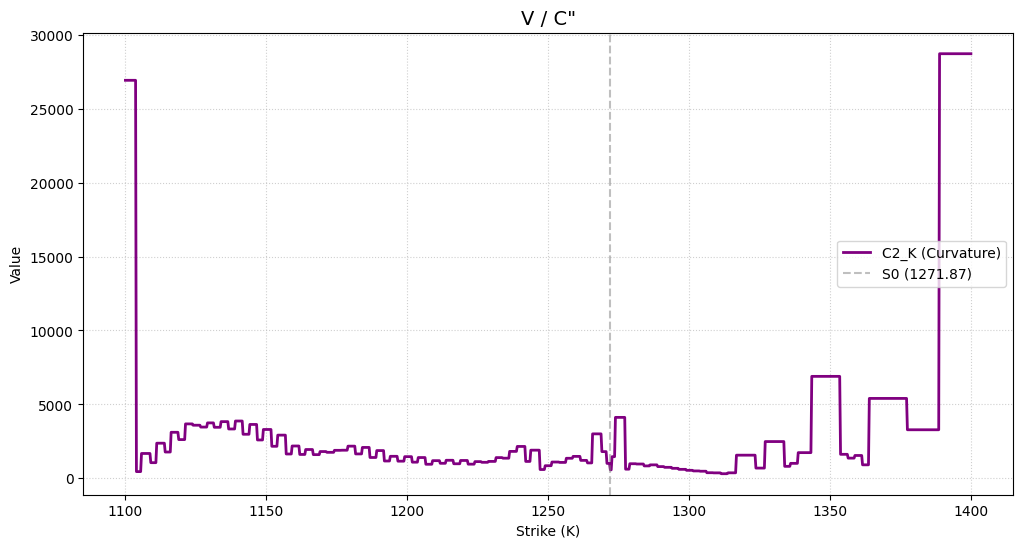

In [214]:
# 1. Pre-calculate c_v values for the optimized theta
c_v1_init, c_v2_init = load_c_values(R1, R2, S0, init_theta)

k_min_plot = 1100
k_max_plot = 1400

# 3. Generate strike range and calculate C2_K
K_range = np.linspace(k_min_plot, k_max_plot, 1000)
c2_values = np.array([C2_over_V(k, R1, R2, S0, init_theta, c_v1_opt, c_v2_opt) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values, color='purple', linewidth=2, label='C2_K (Curvature)')
plt.axvline(S0, color='gray', linestyle='--', alpha=0.5, label=f'S0 ({S0})')

plt.title('V / C"', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [215]:
opt_theta = coordinateDescent(R1, R2, S0, init_theta, market_bid_ask, 0.01, num_indices = (R1 + R2)//10)
opt_sigs = np.concatenate([opt_theta[R1 : 2 * R1], opt_theta[2 * R1 + R2 :]])

Loss: -10.612584


In [216]:
obj_init = newObjective(init_sigs)

obj_opt = newObjective(opt_sigs)

print(f"Initial Obj: {obj_init:.8f}")
print(f"Final Obj:   {obj_opt:.8f}")

Initial Obj: -10.61258440
Final Obj:   -17.25496428


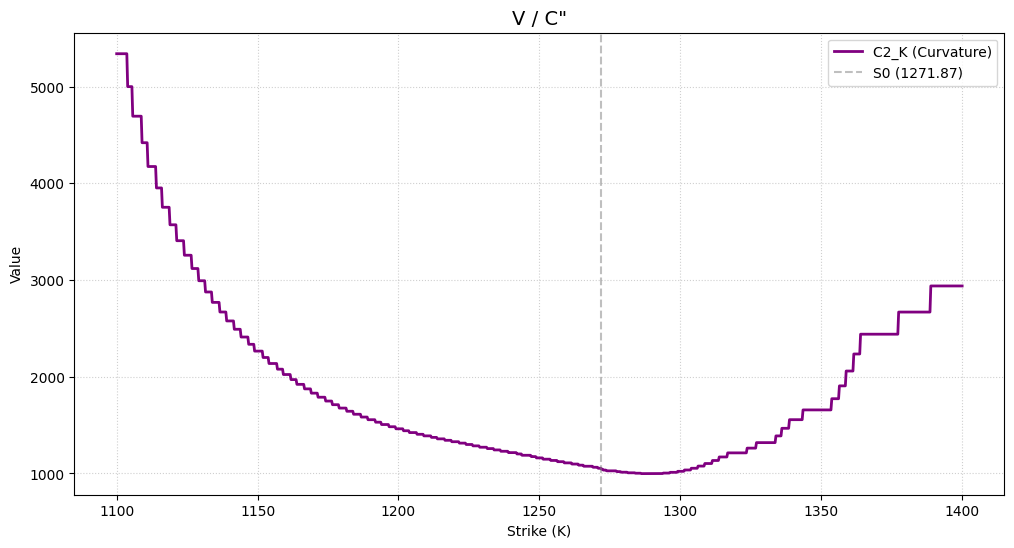

In [217]:
# 1. Pre-calculate c_v values for the optimized theta
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)

k_min_plot = 1100
k_max_plot = 1400

# 3. Generate strike range and calculate C2_K
K_range = np.linspace(k_min_plot, k_max_plot, 1000)
c2_values = np.array([C2_over_V(k, R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values, color='purple', linewidth=2, label='C2_K (Curvature)')
plt.axvline(S0, color='gray', linestyle='--', alpha=0.5, label=f'S0 ({S0})')

plt.title('V / C"', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [218]:
from scipy.stats import norm

def optimize_nus(R1, R2, S0, init_theta, bid_ask_arr, num_additions = 100, tol=1e-5):
    theta = init_theta.copy()

    fac = 140 # Standard Deviation

    sigs = np.concatenate([theta[R1:2*R1], theta[2*R1+R2:]])
    nus = np.concatenate([theta[:R1], [S0], theta[2*R1:2*R1+R2]])

    min_length = np.min(np.diff(nus))

    midpoints = nus[:-1] + np.diff(nus)/2

    # weights = 1/(1+((S0 - midpoints)/fac)**4)

    weights = np.array([norm.pdf(K, loc = S0, scale = fac) for K in nus[:-1]])

    for i in range(num_additions):

        index = np.argmax(np.diff(nus) * weights)

        if (nus[index+1] - nus[index]) < min_length:
            break


        new_nu = (nus[index+1] + nus[index])/2

        new_midpoint1 = (new_nu + nus[index])/2
        new_midpoint2 = (nus[index+1] + new_nu)/2

        # new_weight1 = 1/(1+((S0 - new_midpoint1)/fac)**4)
        # new_weight2 = 1/(1+((S0 - new_midpoint2)/fac)**4)

        new_weight1 = norm.pdf(new_midpoint1, loc = S0, scale = fac)
        new_weight2 = norm.pdf(new_midpoint2, loc = S0, scale = fac)

        weights = np.insert(weights, index + 1, new_weight2)
        weights[index] = new_weight1
        nus = np.insert(nus, index + 1, new_nu)

        if (index < R1):
            nus = np.delete(nus, R1)
            R1 += 1
        else:
            nus = np.delete(nus, R1 + 1)
            R2 += 1

        sigs = np.insert(sigs, index + 1, sigs[index])

        theta = np.concatenate([
            nus[:R1],
            sigs[:R1],
            nus[R1:],
            sigs[R1:]
        ])

        print(f"Added knot at index {index+1}. New R1: {R1}, R2: {R2}")

        theta = coordinateDescentSpecific(R1, R2, S0, theta, bid_ask_arr, index+1, num_indices = (R1+R2)//10)

        sigs = np.concatenate([theta[R1:2*R1], theta[2*R1+R2:]])
        nus = np.concatenate([theta[:R1], [S0], theta[2*R1:2*R1+R2]])

    return R1, R2, theta

In [219]:
print(f"Starting refinement from R1={R1}, R2={R2}")

new_R1, new_R2, refined_theta = optimize_nus(R1, R2, S0, opt_theta, market_bid_ask, num_additions=2000)

refined_sigs = np.concatenate([refined_theta[new_R1 : 2*new_R1], refined_theta[2*new_R1 + new_R2 :]])

Starting refinement from R1=70, R2=34
Added knot at index 104. New R1: 70, R2: 35
Loss: -17.254964
Added knot at index 103. New R1: 70, R2: 36
Loss: -17.258116
Added knot at index 103. New R1: 70, R2: 37
Loss: -17.270484
Added knot at index 105. New R1: 70, R2: 38
Loss: -17.291024
Added knot at index 103. New R1: 70, R2: 39
Loss: -17.296563
Added knot at index 105. New R1: 70, R2: 40
Loss: -17.308562
Added knot at index 2. New R1: 71, R2: 40
Loss: -17.315671
Added knot at index 3. New R1: 72, R2: 40
Loss: -17.318340
Added knot at index 4. New R1: 73, R2: 40
Loss: -17.322745
Added knot at index 110. New R1: 73, R2: 41
Loss: -17.325485
Added knot at index 2. New R1: 74, R2: 41
Loss: -17.336751
Added knot at index 105. New R1: 74, R2: 42
Loss: -17.337633
Added knot at index 115. New R1: 74, R2: 43
Loss: -17.353165
Added knot at index 115. New R1: 74, R2: 44
Loss: -17.355433
Added knot at index 115. New R1: 74, R2: 45
Loss: -17.358896
Added knot at index 108. New R1: 74, R2: 46
Loss: -17.3

In [220]:
obj_refined = newObjective(refined_sigs)

print(f"Original Obj (Initial):   {obj_init:.12f}")
print(f"Optimized Obj (Previous): {obj_opt:.12f}")
print(f"Refined Obj (Final):     {obj_refined:.12f}")

Original Obj (Initial):   -10.612584400861
Optimized Obj (Previous): -17.254964277097
Refined Obj (Final):     -19.154898154432


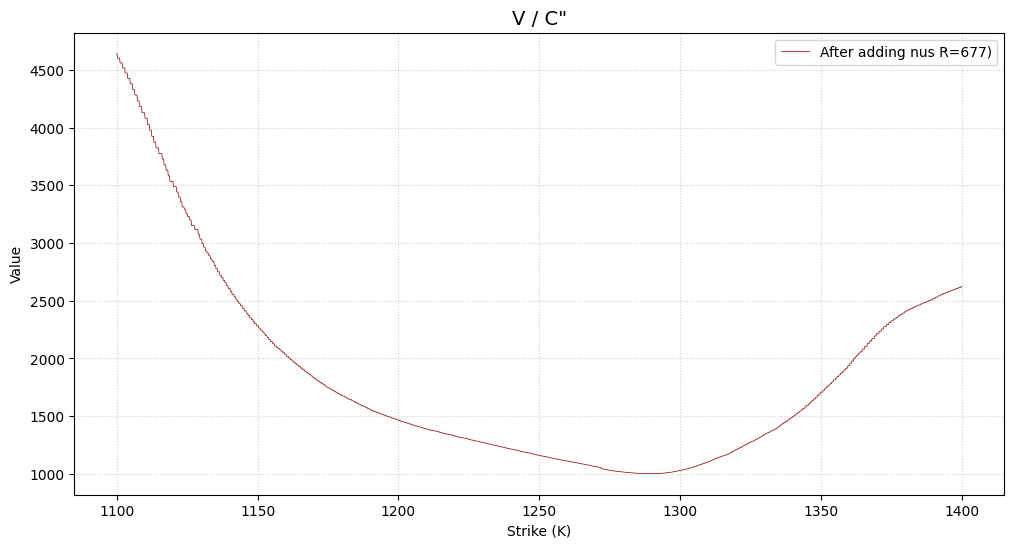

In [221]:
# 1. Pre-calculate c_v values for the refined theta
c_v1_ref, c_v2_ref = load_c_values(new_R1, new_R2, S0, refined_theta)

k_min_plot = 1100
k_max_plot = 1400

# 3. Generate strike range and calculate C2_K
K_range = np.linspace(k_min_plot, k_max_plot, 2000)
c2_values_ref = np.array([C2_over_V(k, new_R1, new_R2, S0, refined_theta, c_v1_ref, c_v2_ref) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values_ref, color='darkred', linewidth=0.5, label=f'After adding nus R={new_R1+new_R2})')

plt.title('V / C"', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [222]:
print(f"Starting secondary CCD refinement from R={new_R1 + new_R2} knots...")
final_theta = coordinateDescent(new_R1, new_R2, S0, refined_theta, market_bid_ask, 0.0001, num_indices=(new_R1 + new_R2)//10)

final_sigs = np.concatenate([final_theta[new_R1 : 2*new_R1], final_theta[2*new_R1 + new_R2 :]])

obj_final = newObjective(final_sigs)

print(f"\nRefined Obj (Previous): {obj_refined:.12f}")
print(f"Final Obj (After CCD):  {obj_final:.12f}")

Starting secondary CCD refinement from R=677 knots...
Loss: -19.154898

Refined Obj (Previous): -19.154898154432
Final Obj (After CCD):  -19.195283462527


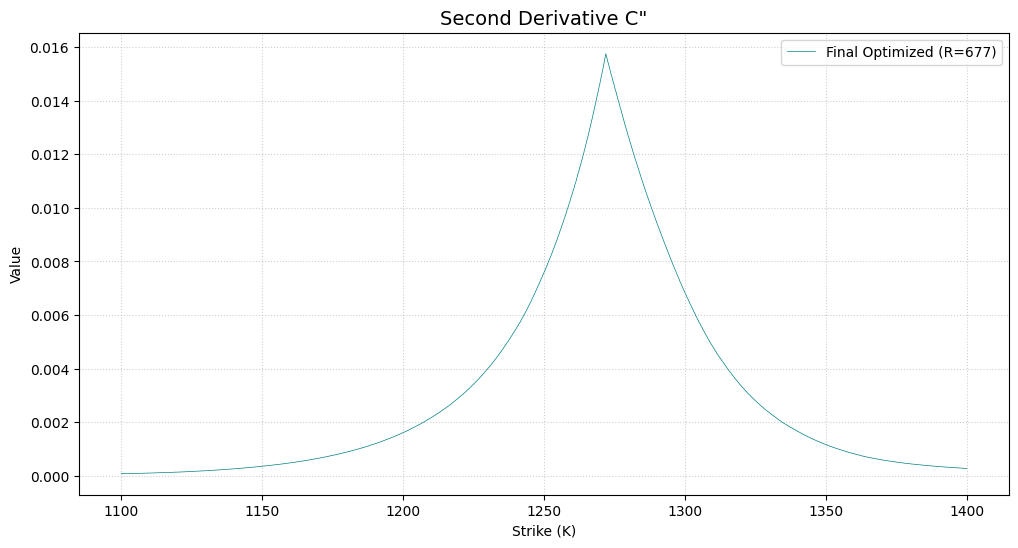

In [223]:
# 1. Pre-calculate c_v values for the final optimized theta
c_v1_fin, c_v2_fin = load_c_values(new_R1, new_R2, S0, final_theta)

k_min_plot = 1100
k_max_plot = 1400
K_range = np.linspace(k_min_plot, k_max_plot, 2000)

# 3. Calculate C2_K
c2_values_final = np.array([C2_K(k, new_R1, new_R2, S0, final_theta, c_v1_fin, c_v2_fin) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values_final, color='teal', linewidth=0.5, label=f'Final Optimized (R={new_R1+new_R2})')

plt.title('Second Derivative C"', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

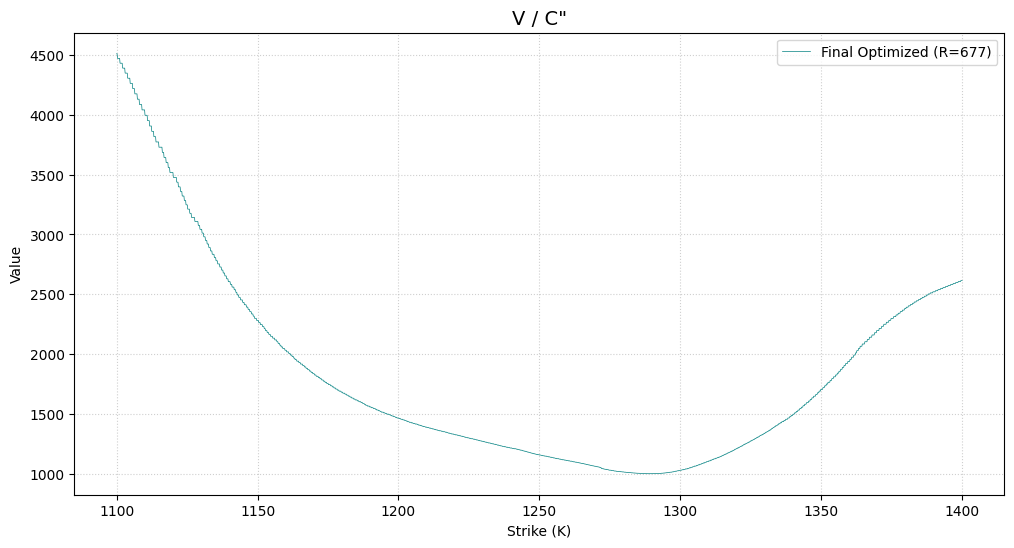

In [224]:
# 1. Pre-calculate c_v values for the final optimized theta
c_v1_fin, c_v2_fin = load_c_values(new_R1, new_R2, S0, final_theta)

k_min_plot = 1100
k_max_plot = 1400
K_range = np.linspace(k_min_plot, k_max_plot, 2000)

# 3. Calculate C2_K
c2_values_final = np.array([C2_over_V(k, new_R1, new_R2, S0, final_theta, c_v1_fin, c_v2_fin) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values_final, color='teal', linewidth=0.5, label=f'Final Optimized (R={new_R1+new_R2})')

plt.title('V / C"', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [225]:
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total notebook execution time: {elapsed_time:.2f} seconds")

Total notebook execution time: 16.00 seconds
